# ML Modeling: Linear Regression Analysis for GDM Association

## Overview
This notebook performs linear regression analysis to determine if there is a significant difference in metabolite levels between GDM positive and non-GDM women, while accounting for covariates. We will analyze cord blood metabolites and calculate effect sizes and adjusted p-values.

## Step 1-2: Set Up Big Loop for Each Metabolite (Cord Data)

We will create a loop that iterates over each metabolite. For cord data:
- Rows = samples  
- Columns = metabolites  
- For each metabolite i: extract metabolite[i] (all rows, ith column)
- Fit model: `lm(metabolite[i] ~ covariates)`

## Setup: Load Core Inputs (Self-Contained)

Loading:
- `cord_matrix` from `CORD_DATA_T`
- covariates and supplements from `src/raw/mata2022_caco_mar242022.xlsx`
- `Sample` IDs from the cord mapping file (for row alignment only)
- `covariate_matrix_num` (aligned to cord sample order)
- `ml_csv_dir` for outputs

In [49]:
# Self-contained setup: load metabolite matrix and build aligned covariate matrix
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Keep imports robust for notebook cwd differences
sys.path.insert(0, str(Path(os.getcwd()).parent.parent))
from src.utils.config import CORD_DATA_T, CORD_ANNO, OUTPUTS_DIR

# 1) Load cord metabolite matrix (rows=samples, columns=metabolites)
cord_matrix = pd.read_csv(CORD_DATA_T, index_col="Sample").astype(float)
cord_matrix.index = cord_matrix.index.astype(str)

# 2) Load raw maternal covariate file (source of supplements + lifestyle covariates)
src_dir = Path(CORD_DATA_T).resolve().parents[2]
mata_path = src_dir / "raw" / "mata2022_caco_mar242022.xlsx"
if not mata_path.exists():
    raise FileNotFoundError(f"Required maternal covariate file not found: {mata_path}")

mata_df = pd.read_excel(mata_path)

# 3) Load Sample ID bridge from cord mapping output (used only for sample alignment)
gdm_map_path = os.path.join(OUTPUTS_DIR, "pca", "output_csv", "06_pc_scores", "cord_mapped_with_pc1_pc2.csv")
if not os.path.exists(gdm_map_path):
    raise FileNotFoundError(f"Required mapping file not found: {gdm_map_path}")

sample_bridge = pd.read_csv(gdm_map_path)
required_bridge_cols = ["Sample", "IDCode"]
missing_bridge = [c for c in required_bridge_cols if c not in sample_bridge.columns]
if missing_bridge:
    raise ValueError(f"Mapping file missing required columns: {missing_bridge}")

sample_bridge = sample_bridge[required_bridge_cols].copy()
sample_bridge["Sample"] = sample_bridge["Sample"].astype(str).str.strip()
sample_bridge = sample_bridge[sample_bridge["Sample"].str.len() > 0]
sample_bridge["IDCode"] = pd.to_numeric(sample_bridge["IDCode"], errors="coerce")
sample_bridge = sample_bridge.dropna(subset=["IDCode"]).drop_duplicates(subset=["Sample"], keep="first")

# 4) Merge raw maternal covariates to Sample IDs via IDCode
map_df = sample_bridge.merge(mata_df, on="IDCode", how="left")
map_df = map_df.drop_duplicates(subset=["Sample"], keep="first").set_index("Sample")

# 5) Resolve required covariates by aliases
covariate_aliases = {
    "maternal_age": ["Ma_age", "maternal_age"],
    "bmi": ["pre_BMI_new", "BMI", "Ma_BMI"],
    "diet_protein": ["diet_protein", "protein", "protein_intake"],
    "diet_fruit_vegetables": ["diet_vegfruit", "fruit_vegetable", "fruit_veg"],
    "physical_activity": ["O2_PHYSACTIV", "physical_activity", "phys_activity", "O1_JOBACTIVITY"],
}

supplement_aliases = {
    "supp_multivitamin": ["p4_MULTIVITAMIN", "multivitamin"],
    "supp_calcium": ["p4_CALCIUM", "calcium"],
    "supp_folate": ["p4_FOLATE", "folate", "folic_acid"],
    "supp_fishoil": ["p4_FISHOIL", "fishoil", "fish_oil"],
    "supp_zinc": ["p4_ZINC", "zinc"],
    "supp_vitamin_e": ["p4_VITE", "vitamin_e", "vite"],
}

selected_covariates = {}
for label, aliases in covariate_aliases.items():
    selected = next((col for col in aliases if col in map_df.columns), None)
    if selected is not None:
        selected_covariates[label] = selected

if not selected_covariates:
    raise ValueError("None of the requested numeric covariates were found in maternal covariate file.")

selected_supplements = {}
for label, aliases in supplement_aliases.items():
    selected = next((col for col in aliases if col in map_df.columns), None)
    if selected is not None:
        selected_supplements[label] = selected

missing_supps = [k for k in supplement_aliases if k not in selected_supplements]
if missing_supps:
    raise ValueError(f"Missing supplement columns required for derived variables: {missing_supps}")

# 6) Align covariate rows to cord matrix row order
sample_order = cord_matrix.index
ordered_source_cols = ["GDM"] + list(selected_covariates.values())
if "GDM" not in map_df.columns:
    raise ValueError("GDM column not found after merging maternal covariates.")

covariate_matrix_raw = map_df.reindex(sample_order)[ordered_source_cols].copy()
covariate_matrix_raw.index.name = "Sample"

rename_map = {"GDM": "GDM"}
rename_map.update({src: label for label, src in selected_covariates.items()})
covariate_matrix_raw = covariate_matrix_raw.rename(columns=rename_map)

# 7) Build supplement-derived variables
supplement_source_df = map_df.reindex(sample_order)[list(selected_supplements.values())].copy()
supplement_source_df = supplement_source_df.rename(columns={v: k for k, v in selected_supplements.items()})


def to_binary_use(series: pd.Series) -> pd.Series:
    s = pd.to_numeric(series, errors="coerce")
    observed = set(s.dropna().unique())
    if not observed:
        return pd.Series(np.nan, index=s.index, dtype=float)
    if observed.issubset({1, 2}):
        return s.map({1: 0.0, 2: 1.0})
    if observed.issubset({0, 1}):
        return s.astype(float)
    out = np.where(s.isna(), np.nan, (s > 0).astype(float))
    return pd.Series(out, index=s.index, dtype=float)

supp_binary = supplement_source_df.apply(to_binary_use)

core3_cols = ["supp_multivitamin", "supp_calcium", "supp_folate"]
all6_cols = [
    "supp_multivitamin", "supp_calcium", "supp_folate",
    "supp_fishoil", "supp_zinc", "supp_vitamin_e",
]

core3_df = supp_binary[core3_cols]
all6_df = supp_binary[all6_cols]

core3_any = (core3_df == 1).any(axis=1).astype(float)
core3_all_missing = core3_df.isna().all(axis=1)
all6_any = (all6_df == 1).any(axis=1).astype(float)
all6_all_missing = all6_df.isna().all(axis=1)

covariate_matrix_raw["supp_any_mvf_ca_fol"] = np.where(core3_all_missing, np.nan, core3_any)
covariate_matrix_raw["supp_any_of_6"] = np.where(all6_all_missing, np.nan, all6_any)

# 8) Type handling: GDM categorical binary (0/1), others numeric
covariate_matrix_num = covariate_matrix_raw.copy()
gdm_numeric = pd.to_numeric(covariate_matrix_num["GDM"], errors="coerce")
covariate_matrix_num["GDM"] = pd.Categorical(gdm_numeric, categories=[0, 1])

numeric_covariates = [c for c in covariate_matrix_num.columns if c != "GDM"]
covariate_matrix_num[numeric_covariates] = covariate_matrix_num[numeric_covariates].apply(pd.to_numeric, errors="coerce")

# Store covariates in the requested variable name
cov_matrix = covariate_matrix_num.copy()

# 9) Output directory for this analysis
ml_csv_dir = os.path.join(OUTPUTS_DIR, "ml_modeling", "output_csv", "08_cord_gdm")
os.makedirs(ml_csv_dir, exist_ok=True)

print("Setup complete")
print("Cord matrix shape:", cord_matrix.shape)
print("Covariate matrix shape:", cov_matrix.shape)
print("GDM dtype:", cov_matrix["GDM"].dtype)
print("Resolved numeric covariates:", numeric_covariates)
print("Maternal source file:", mata_path)
print("Output dir:", ml_csv_dir)

Setup complete
Cord matrix shape: (38, 981)
Covariate matrix shape: (38, 8)
GDM dtype: category
Resolved numeric covariates: ['maternal_age', 'bmi', 'diet_protein', 'diet_fruit_vegetables', 'physical_activity', 'supp_any_mvf_ca_fol', 'supp_any_of_6']
Maternal source file: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/raw/mata2022_caco_mar242022.xlsx
Output dir: /Users/aishvarya/Library/CloudStorage/OneDrive-UniversityatBuffalo/Desktop/Project/Metabolomics/Metabolomics_Project/src/../outputs/ml_modeling/output_csv/08_cord_gdm


In [57]:
cord_matrix.head()

,107004,108005,109011,1101001,1101006,1102005,1102011,1102012,1102017,1102018,...,675024,675025,675026,675027,675028,675029,676007,677004,677011,634009
Sample,,,,,,,,,,,,,,,,,,,,,
sample-1,0.982920,0.997001,1.001218,1.001201,1.040406,1.000000,0.979128,0.897300,1.049986,0.918842,...,0.998943,0.995692,0.993673,1.006100,0.989948,0.995593,0.990328,0.977754,0.985770,0.976144
sample-2,0.991572,1.024139,1.014588,1.019298,0.853199,0.881035,1.010385,0.931008,1.059620,0.908615,...,1.001057,0.996019,1.003748,0.992310,1.000658,0.994897,1.012718,1.005144,1.000231,1.017369
sample-3,0.962144,0.972625,0.999607,0.891771,0.953293,1.001158,0.869336,0.897300,0.834241,0.908615,...,0.988019,0.990972,0.980308,0.982788,0.994468,0.983981,1.004100,0.979684,0.980854,0.961003
sample-4,1.005908,1.015966,1.000671,0.891771,0.853199,1.022224,0.869336,0.897300,0.943810,0.908615,...,0.983763,0.985011,0.993704,0.997537,0.998984,0.989069,1.023485,0.991362,0.981521,0.983039
sample-5,0.888982,0.989501,0.995799,1.092085,0.925969,1.022152,0.869336,0.897300,0.915130,0.908615,...,1.013374,1.007367,0.996035,0.987062,0.997701,1.008544,0.935841,0.986891,0.995214,0.979196


In [44]:
# Step 3: Load and Preview Cord Metabolite Data
# Load cord metabolite matrix (rows=samples, columns=metabolites)

cord_matrix = pd.read_csv(CORD_DATA_T, index_col="Sample").astype(float)
cord_matrix.index = cord_matrix.index.astype(str)

# Verify the data loaded correctly
print("Cord metabolite data shape:", cord_matrix.shape)
print("First 10 metabolite names:", cord_matrix.columns[:10])  # Show first 10 metabolite names
print("Cord data samples:", cord_matrix.index)


Cord metabolite data shape: (38, 981)
First 10 metabolite names: Index(['107004', '108005', '109011', '1101001', '1101006', '1102005',
       '1102011', '1102012', '1102017', '1102018'],
      dtype='object')
Cord data samples: Index(['sample-1', 'sample-2', 'sample-3', 'sample-4', 'sample-5', 'sample-6',
       'sample-7', 'sample-8', 'sample-9', 'sample-10', 'sample-11',
       'sample-12', 'sample-13', 'sample-14', 'sample-15', 'sample-16',
       'sample-17', 'sample-18', 'sample-19', 'sample-20', 'sample-21',
       'sample-22', 'sample-23', 'sample-24', 'sample-25', 'sample-26',
       'sample-27', 'sample-28', 'sample-29', 'sample-30', 'sample-31',
       'sample-32', 'sample-33', 'sample-34', 'sample-35', 'sample-36',
       'sample-37', 'sample-38'],
      dtype='object', name='Sample')


## Step 4: Create Covariate Matrix

Create a matrix of covariates that associates with cord blood samples. The order must match the metabolite data.

**Covariates to include:**
- Maternal age
- BMI
- Diet (protein, fruit&vegetables)
- Physical activity
- Supplements (special handling):
  - **Variable 1:** Any of (Multivitamin, Calcium, Folate) = 1, else 0
  - **Variable 2:** Any of all 6 (Multivitamin, Calcium, Folate, Fishoil, Zinc, Vitamin E) = 1, else 0

In [56]:
# Step 4: Create covariate matrix aligned with cord samples
# cov_matrix = covariates that associate with the samples of cord blood
# Must be ordered in the same way as cord_matrix (rows match by sample ID)

# Verify covariate data is loaded and aligned
print("Covariate matrix shape:", cov_matrix.shape)
print("Covariate columns:", cov_matrix.columns.tolist())
print("Number of samples in covariates:", len(cov_matrix))

# Check alignment: cord samples vs covariate samples
cord_samples = set(cord_matrix.index)
cov_samples = set(cov_matrix.index)

print(f"\nCord samples: {len(cord_samples)}")
print(f"Covariate samples: {len(cov_samples)}")
print(f"Overlap: {len(cord_samples & cov_samples)}")

Covariate matrix shape: (38, 8)
Covariate columns: ['GDM', 'maternal_age', 'bmi', 'diet_protein', 'diet_fruit_vegetables', 'physical_activity', 'supp_any_mvf_ca_fol', 'supp_any_of_6']
Number of samples in covariates: 38

Cord samples: 38
Covariate samples: 38
Overlap: 38


In [55]:
cov_matrix.head()

,GDM,maternal_age,bmi,diet_protein,diet_fruit_vegetables,physical_activity,supp_any_mvf_ca_fol,supp_any_of_6
Sample,,,,,,,,
sample-1,0,34,28.040378,4.50,4.5,2.0,1.0,1.0
sample-2,1,28,25.217359,3.25,4.5,2.0,1.0,1.0
sample-3,0,28,24.242424,12.50,12.5,2.0,1.0,1.0
sample-4,1,37,22.375680,8.50,24.0,1.0,1.0,1.0
sample-5,0,32,20.195578,30.00,30.0,2.0,NaN,NaN


## Step 5: Check for Missing Covariates and Data Cleaning

- Drop rows/samples with missing covariates
- Expected: 4 samples have missing values → should drop 4 columns, leaving 34 out of 38 samples
- Ensure all numeric covariates are numeric data type (no strings)
- GDM should be a binary categorical variable (0 & 1) modeled as a factor

In [65]:
# Step 5: Check for missing covariates and clean data
import numpy as np

# Check for missing values in covariate matrix
print("Missing values by covariate:")
print(covariate_matrix_num.isnull().sum())
print(f"\nTotal missing values: {covariate_matrix_num.isnull().sum().sum()}")


Missing values by covariate:
GDM                      0
maternal_age             0
bmi                      0
diet_protein             1
diet_fruit_vegetables    1
physical_activity        3
supp_any_mvf_ca_fol      3
supp_any_of_6            3
dtype: int64

Total missing values: 11


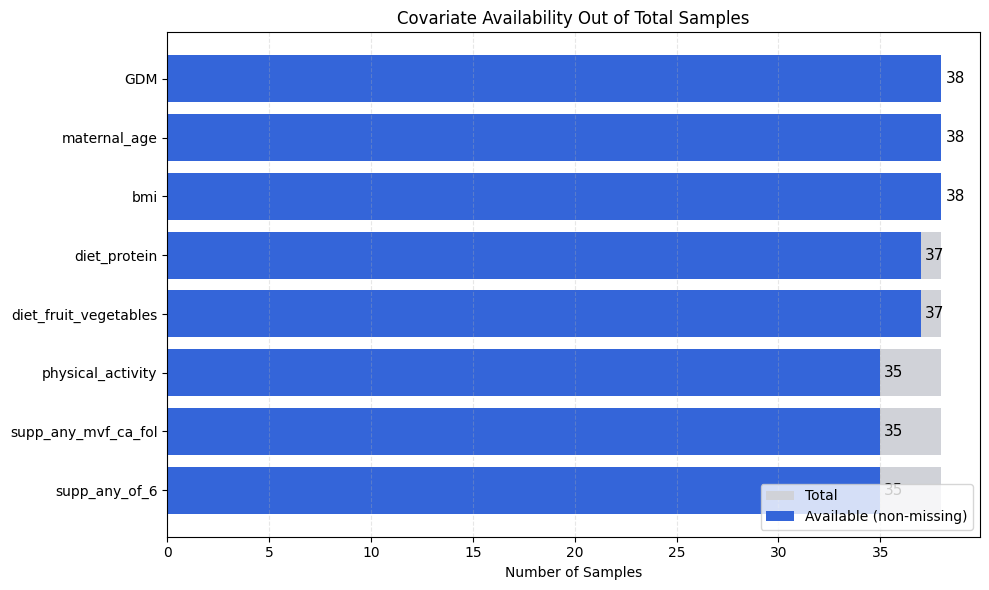

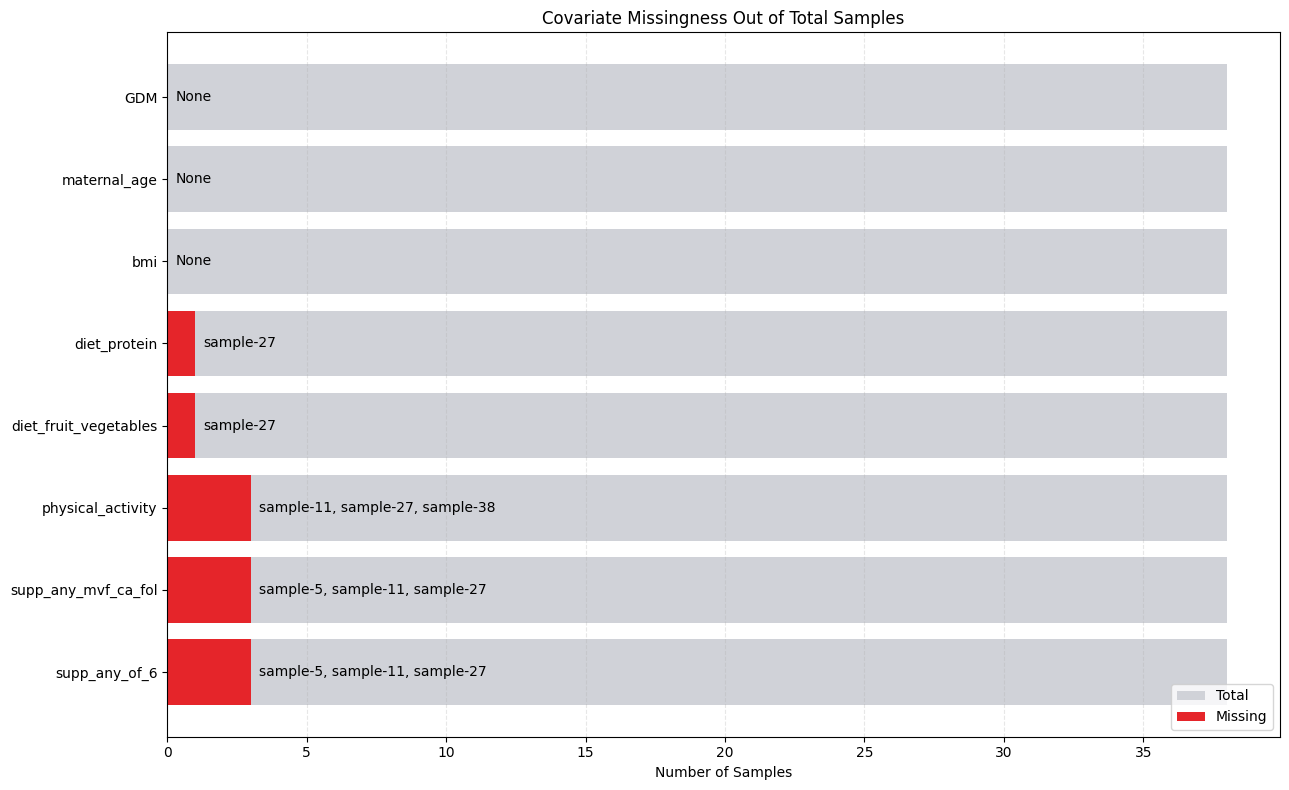

In [75]:
# Step 5 Visualization: Availability and missingness bars (like reference)
import matplotlib.pyplot as plt

# Counts per covariate
total_n = len(cov_matrix)
missing_counts = cov_matrix.isna().sum()
available_counts = total_n - missing_counts

# Sort to match the style in reference plots
plot_order = available_counts.sort_values(ascending=False).index.tolist()

# Build text labels listing which samples are missing per covariate
missing_sample_labels = {}
for col in plot_order:
    missing_samples = cov_matrix.index[cov_matrix[col].isna()].tolist()
    missing_sample_labels[col] = ", ".join(missing_samples) if missing_samples else "None"

# 1) Availability out of total
fig, ax = plt.subplots(figsize=(10, 6))
ypos = range(len(plot_order))
ax.barh(ypos, [total_n] * len(plot_order), color="#d0d2d8", label="Total")
ax.barh(ypos, [available_counts[c] for c in plot_order], color="#3465d9", label="Available (non-missing)")

ax.set_yticks(list(ypos))
ax.set_yticklabels(plot_order)
ax.invert_yaxis()
ax.set_xlabel("Number of Samples")
ax.set_title("Covariate Availability Out of Total Samples")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")

for i, c in enumerate(plot_order):
    ax.text(available_counts[c] + 0.2, i, f"{int(available_counts[c])}", va="center", fontsize=11)

plt.tight_layout()
plt.show()

# 2) Missingness out of total + missing sample names
fig, ax = plt.subplots(figsize=(13, 8))
ax.barh(ypos, [total_n] * len(plot_order), color="#d0d2d8", label="Total")
ax.barh(ypos, [missing_counts[c] for c in plot_order], color="#e5252a", label="Missing")

ax.set_yticks(list(ypos))
ax.set_yticklabels(plot_order)
ax.invert_yaxis()
ax.set_xlabel("Number of Samples")
ax.set_title("Covariate Missingness Out of Total Samples")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")

for i, c in enumerate(plot_order):
    ax.text(missing_counts[c] + 0.3, i, missing_sample_labels[c], va="center", fontsize=10)

plt.tight_layout()
plt.show()

In [67]:
# Remove samples with any missing covariates
cov_clean = covariate_matrix_num.dropna()
print(f"\nOriginal samples: {len(covariate_matrix_num)}")
print(f"Samples after removing missing: {len(cov_clean)}")
print(f"Samples dropped: {len(covariate_matrix_num) - len(cov_clean)}")


Original samples: 38
Samples after removing missing: 34
Samples dropped: 4


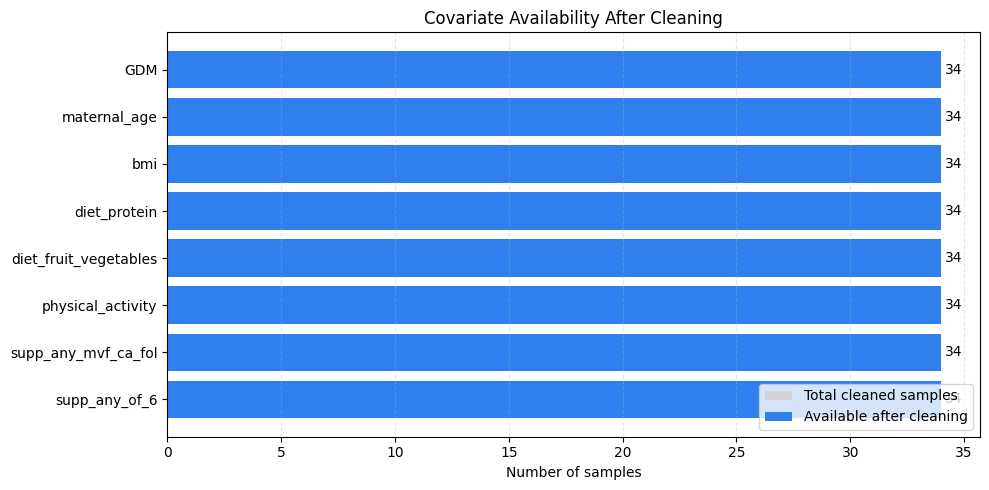

In [77]:
# Visualization after cleaning: covariate availability in cleaned dataset
import matplotlib.pyplot as plt

clean_n = len(cov_clean)
available_after_clean = cov_clean.notna().sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ypos = range(len(available_after_clean))

# Total rows in cleaned set is the same for all covariates (shown as background)
ax.barh(ypos, [clean_n] * len(available_after_clean), color="#d0d2d8", label="Total cleaned samples")
ax.barh(ypos, available_after_clean.values, color="#2F80ED", label="Available after cleaning")

ax.set_yticks(list(ypos))
ax.set_yticklabels(available_after_clean.index)
ax.invert_yaxis()
ax.set_xlabel("Number of samples")
ax.set_title("Covariate Availability After Cleaning")
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.legend(loc="lower right")

for i, val in enumerate(available_after_clean.values):
    ax.text(val + 0.15, i, str(int(val)), va="center", fontsize=10)

plt.tight_layout()
plt.show()

In [68]:
# Filter cord data to match available covariate samples
cord_clean = cord_matrix.loc[cov_clean.index]
print(f"\nCord data shape after matching: {cord_clean.shape}")


Cord data shape after matching: (34, 981)


In [69]:
# Ensure all covariates are numeric except GDM
print("\nData types in cleaned covariate matrix:")
print(cov_clean.dtypes)


Data types in cleaned covariate matrix:
GDM                      category
maternal_age                int64
bmi                       float64
diet_protein              float64
diet_fruit_vegetables     float64
physical_activity         float64
supp_any_mvf_ca_fol       float64
supp_any_of_6             float64
dtype: object


## Steps 6-13: Main Loop - Fit Models and Extract Statistics

For each metabolite i:
1. Extract metabolite column i
2. Fit: `lm(metabolite[i] ~ GDM + covariates)`
3. Extract p-value for GDM coefficient
4. Calculate mean for GDM=1 group
5. Calculate mean for GDM=0 group
6. Calculate fold change (GDM/non-GDM)
7. Calculate log fold change
8. Convert to raw fold change (2^log_fc)
9. Store all values in vectors

**Stored vectors:**
- p_store: p-values for GDM
- m_GDM_store: means for GDM=1
- m_non_GDM_store: means for GDM=0
- fc_store: fold changes
- log_fc_store: log fold changes
- raw_fc_store: raw fold changes

In [32]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Initialize storage vectors for results
p_store = []                    # p-values for GDM
m_GDM_store = []               # mean for GDM=1 group
m_non_GDM_store = []           # mean for GDM=0 group
fc_store = []                  # fold change (GDM / non-GDM)
log_fc_store = []              # log fold change
raw_fc_store = []              # raw fold change (2^log_fc)
metabolite_names = []          # metabolite names for tracking

# Get metabolite column names
metabolite_cols = cord_clean.columns

print(f"Starting loop over {len(metabolite_cols)} metabolites...")

# STEP 6-13: BIG LOOP - Go through each metabolite
for i, metabolite in enumerate(metabolite_cols):
    # Extract metabolite column (all rows, ith column)
    metabolite_data = cord_clean[metabolite]
    
    # Prepare model data
    model_data = cov_clean.copy()
    model_data['metabolite'] = metabolite_data
    
    # Ensure GDM is categorical (factor)
    if 'GDM' in model_data.columns:
        model_data['GDM'] = model_data['GDM'].astype('category')
    
    # Fit linear model: lm(metabolite ~ GDM + covariates)
    # Set GDM and other covariates for the formula
    formula = 'metabolite ~ GDM + ' + ' + '.join([col for col in cov_clean.columns if col != 'GDM'])
    
    try:
        fit = sm.formula.ols(formula, data=model_data).fit()
        
        # Step 6: Extract p-value for GDM coefficient
        gdm_pval = fit.pvalues['GDM[T.1]'] if 'GDM[T.1]' in fit.pvalues.index else fit.pvalues.get('GDM', np.nan)
        p_store.append(gdm_pval)
        
        # Step 8: Calculate mean for GDM=1 group
        gdm_mean = metabolite_data[cov_clean['GDM'] == 1].mean()
        m_GDM_store.append(gdm_mean)
        
        # Step 9: Calculate mean for GDM=0 group
        non_gdm_mean = metabolite_data[cov_clean['GDM'] == 0].mean()
        m_non_GDM_store.append(non_gdm_mean)
        
        # Step 10: Calculate fold change
        fc = gdm_mean / non_gdm_mean if non_gdm_mean != 0 else np.nan
        fc_store.append(fc)
        
        # Step 11: Calculate log fold change
        log_fc = gdm_mean - non_gdm_mean  # On log scale
        log_fc_store.append(log_fc)
        
        # Step 12: Convert back to raw fold change
        raw_fc = 2 ** log_fc  # Assuming log2 transformation
        raw_fc_store.append(raw_fc)
        
        metabolite_names.append(metabolite)
        
        if (i + 1) % 100 == 0:
            print(f"Processed {i + 1} metabolites...")
            
    except Exception as e:
        print(f"Error fitting model for metabolite {metabolite}: {e}")
        p_store.append(np.nan)
        m_GDM_store.append(np.nan)
        m_non_GDM_store.append(np.nan)
        fc_store.append(np.nan)
        log_fc_store.append(np.nan)
        raw_fc_store.append(np.nan)
        metabolite_names.append(metabolite)

print(f"\nCompleted loop. Processed {len(metabolite_names)} metabolites.")

Starting loop over 981 metabolites...
Processed 100 metabolites...
Processed 200 metabolites...
Processed 300 metabolites...
Processed 400 metabolites...
Processed 500 metabolites...
Processed 600 metabolites...
Processed 700 metabolites...
Processed 800 metabolites...
Processed 900 metabolites...

Completed loop. Processed 981 metabolites.


## Step 14: Exit Loop and Prepare for Multiple Testing Correction

Convert stored vectors to arrays for further processing:
- p_store: raw p-values
- m_GDM_store: mean metabolite levels in GDM=1 group
- m_non_GDM_store: mean metabolite levels in GDM=0 group
- fc_store: fold changes
- log_fc_store: log fold changes
- raw_fc_store: raw fold changes

In [33]:
# Step 14: Convert to arrays for further processing
p_array = np.array(p_store)
m_gdm_array = np.array(m_GDM_store)
m_non_gdm_array = np.array(m_non_GDM_store)
fc_array = np.array(fc_store)
log_fc_array = np.array(log_fc_store)
raw_fc_array = np.array(raw_fc_store)

print("Results vectors prepared:")
print(f"  p-values: {len(p_array)}")
print(f"  GDM means: {len(m_gdm_array)}")
print(f"  Non-GDM means: {len(m_non_gdm_array)}")
print(f"  Fold changes: {len(fc_array)}")
print(f"  Log fold changes: {len(log_fc_array)}")
print(f"  Raw fold changes: {len(raw_fc_array)}")

print(f"\nP-value summary:")
print(f"  Min: {np.nanmin(p_array):.4e}")
print(f"  Max: {np.nanmax(p_array):.4e}")
print(f"  Mean: {np.nanmean(p_array):.4e}")
print(f"  Median: {np.nanmedian(p_array):.4e}")

Results vectors prepared:
  p-values: 981
  GDM means: 981
  Non-GDM means: 981
  Fold changes: 981
  Log fold changes: 981
  Raw fold changes: 981

P-value summary:
  Min: nan
  Max: nan
  Mean: nan
  Median: nan


/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/2812584536.py:18: RuntimeWarning: All-NaN slice encountered
  print(f"  Min: {np.nanmin(p_array):.4e}")
/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/2812584536.py:19: RuntimeWarning: All-NaN slice encountered
  print(f"  Max: {np.nanmax(p_array):.4e}")
/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/2812584536.py:20: RuntimeWarning: Mean of empty slice
  print(f"  Mean: {np.nanmean(p_array):.4e}")
/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/2812584536.py:21: RuntimeWarning: All-NaN slice encountered
  print(f"  Median: {np.nanmedian(p_array):.4e}")


## Step 15: Calculate Adjusted P-values Using Benjamini-Hochberg

Apply Benjamini-Hochberg (FDR) correction to the p-value vector to control false discovery rate across all metabolite tests.

In [35]:
from statsmodels.stats.multitest import multipletests

# Step 15: Calculate adjusted p-values using Benjamini-Hochberg
# multipletests returns: (reject, pvals_corrected, alphacSidak, alphacBonf)
reject_bh, pvals_adj_bh, _, _ = multipletests(p_array, method='fdr_bh')

print(f"Benjamini-Hochberg Correction Results:")
print(f"  Number of significant metabolites (FDR < 0.05): {reject_bh.sum()}")
print(f"  Min adjusted p-value: {np.nanmin(pvals_adj_bh):.4e}")
print(f"  Max adjusted p-value: {np.nanmax(pvals_adj_bh):.4e}")
print(f"  Mean adjusted p-value: {np.nanmean(pvals_adj_bh):.4e}")
print(f"  Median adjusted p-value: {np.nanmedian(pvals_adj_bh):.4e}")

Benjamini-Hochberg Correction Results:
  Number of significant metabolites (FDR < 0.05): 0
  Min adjusted p-value: nan
  Max adjusted p-value: nan
  Mean adjusted p-value: nan
  Median adjusted p-value: nan


/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/595858063.py:9: RuntimeWarning: All-NaN slice encountered
  print(f"  Min adjusted p-value: {np.nanmin(pvals_adj_bh):.4e}")
/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/595858063.py:10: RuntimeWarning: All-NaN slice encountered
  print(f"  Max adjusted p-value: {np.nanmax(pvals_adj_bh):.4e}")
/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/595858063.py:11: RuntimeWarning: Mean of empty slice
  print(f"  Mean adjusted p-value: {np.nanmean(pvals_adj_bh):.4e}")
/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/595858063.py:12: RuntimeWarning: All-NaN slice encountered
  print(f"  Median adjusted p-value: {np.nanmedian(pvals_adj_bh):.4e}")


## Step 16: Calculate Q-values

Q-values provide another measure of statistical significance considering the proportion of false discoveries.
This uses the qvalue method (Storey's approach) to estimate the FDR at each p-value threshold.

In [36]:
# Step 16: Calculate q-values
# Try using the qvalue package, or fall back to Benjamini-Hochberg if not available
try:
    from qvalue import qvalue
    q_vals = qvalue(p_array)['qvalues']
    print("Q-values calculated using qvalue package")
except ImportError:
    print("qvalue package not available, using Benjamini-Hochberg adjusted p-values as approximation")
    q_vals = pvals_adj_bh
    
print(f"\nQ-value Summary:")
print(f"  Min: {np.nanmin(q_vals):.4e}")
print(f"  Max: {np.nanmax(q_vals):.4e}")
print(f"  Mean: {np.nanmean(q_vals):.4e}")
print(f"  Median: {np.nanmedian(q_vals):.4e}")

qvalue package not available, using Benjamini-Hochberg adjusted p-values as approximation

Q-value Summary:
  Min: nan
  Max: nan
  Mean: nan
  Median: nan


/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/1122652347.py:12: RuntimeWarning: All-NaN slice encountered
  print(f"  Min: {np.nanmin(q_vals):.4e}")
/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/1122652347.py:13: RuntimeWarning: All-NaN slice encountered
  print(f"  Max: {np.nanmax(q_vals):.4e}")
/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/1122652347.py:14: RuntimeWarning: Mean of empty slice
  print(f"  Mean: {np.nanmean(q_vals):.4e}")
/var/folders/sr/fhmynx096tj9ll1v797d66rw0000gn/T/ipykernel_8280/1122652347.py:15: RuntimeWarning: All-NaN slice encountered
  print(f"  Median: {np.nanmedian(q_vals):.4e}")


## Step 17: Create Results Table

Combine all results into a comprehensive table containing:
1. **Metabolite Annotation** - metabolite names/IDs
2. **p-value (raw)** - unadjusted p-values from linear models
3. **p-value (corrected)** - Benjamini-Hochberg adjusted p-values
4. **q-value** - Storey's q-values
5. **Mean GDM** - mean metabolite level in GDM positive women
6. **Mean Non-GDM** - mean metabolite level in non-GDM women
7. **Log Fold Change** - log-scale difference between groups
8. **Raw Fold Change** - back-transformed fold change (2^log_fc)

In [37]:
# Step 17: Create comprehensive results table

# Get metabolite annotations if available
if CORD_ANNO is not None:
    anno_df = pd.read_csv(CORD_ANNO, index_col=0)
else:
    anno_df = None

# Create results dataframe
results_df = pd.DataFrame({
    'Metabolite': metabolite_names,
    'p_value_raw': p_array,
    'p_value_corrected': pvals_adj_bh,
    'q_value': q_vals,
    'Mean_GDM': m_gdm_array,
    'Mean_Non_GDM': m_non_gdm_array,
    'Log_Fold_Change': log_fc_array,
    'Raw_Fold_Change': raw_fc_array
})

# Add metabolite annotation if available
if anno_df is not None:
    # Map metabolite names to annotations
    anno_mapping = anno_df.to_dict('index')
    
    # Add annotation columns
    annotation_cols = []
    for met in metabolite_names:
        if met in anno_mapping:
            annotation_cols.append(anno_mapping[met])
        else:
            annotation_cols.append({col: None for col in anno_df.columns})
    
    anno_expanded = pd.DataFrame(annotation_cols)
    results_df = pd.concat([results_df, anno_expanded], axis=1)

# Sort by p-value (most significant first)
results_df = results_df.sort_values('p_value_raw')

print("Results Table Summary:")
print(f"  Total metabolites: {len(results_df)}")
print(f"\nFirst 10 rows (sorted by p-value):")
print(results_df.head(10))

print(f"\nStatistics:")
print(f"  Significant at FDR < 0.05: {(results_df['p_value_corrected'] < 0.05).sum()}")
print(f"  Significant at p < 0.001: {(results_df['p_value_raw'] < 0.001).sum()}")
print(f"  Significant at p < 0.01: {(results_df['p_value_raw'] < 0.01).sum()}")
print(f"  Significant at p < 0.05: {(results_df['p_value_raw'] < 0.05).sum()}")

Results Table Summary:
  Total metabolites: 981

First 10 rows (sorted by p-value):
  Metabolite  p_value_raw  p_value_corrected  q_value  Mean_GDM  Mean_Non_GDM  \
0     107004          NaN                NaN      NaN       NaN           NaN   
1     108005          NaN                NaN      NaN       NaN           NaN   
2     109011          NaN                NaN      NaN       NaN           NaN   
3    1101001          NaN                NaN      NaN       NaN           NaN   
4    1101006          NaN                NaN      NaN       NaN           NaN   
5    1102005          NaN                NaN      NaN       NaN           NaN   
6    1102011          NaN                NaN      NaN       NaN           NaN   
7    1102012          NaN                NaN      NaN       NaN           NaN   
8    1102017          NaN                NaN      NaN       NaN           NaN   
9    1102018          NaN                NaN      NaN       NaN           NaN   

   Log_Fold_Change  Raw_

In [ ]:
# Save results to CSV
results_path = os.path.join(ml_csv_dir, 'cord_metabolite_gdm_ols_results.csv')
results_df.to_csv(results_path, index=False)
print(f"\nResults saved to: {results_path}")
print(f"Shape: {results_df.shape}")
print(f"Columns: {results_df.columns.tolist()}")